In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os
import sqlite3

import matplotlib.pyplot as plt
import torch
import numpy as np
import scipy

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, precision_recall_curve, auc




In [8]:
df = pd.read_parquet('bge/downsample/downsampled_bge_m3_1024d.parquet')
X = np.load("bge/downsample/downsampled_bge_m3_1024d.npy")
print(X.shape, X.dtype)
df["label"]= df['label'].apply(lambda x: 0 if x=='safe' else 1)
y = df["label"].astype(int).values

(16896, 1024) float32


In [7]:
df.label.value_counts()

label
safe    14080
risk     2816
Name: count, dtype: int64

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y, stratify=y, test_size=0.2, random_state=42)


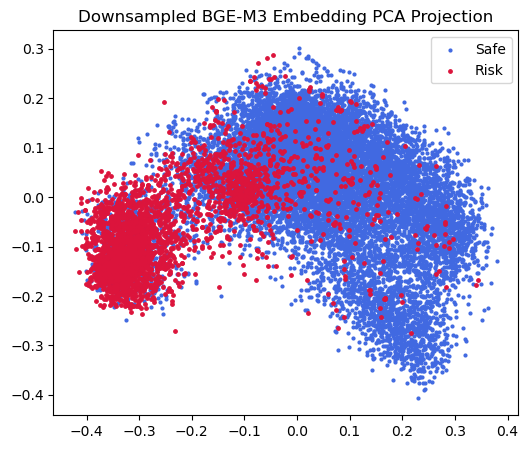

Explained variance: [0.07401983 0.03288465]


In [10]:
pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(X)    

plt.figure(figsize=(6,5))
plt.scatter(proj[y==0,0], proj[y==0,1], s=4, color='royalblue', label='Safe')
plt.scatter(proj[y==1,0], proj[y==1,1], s=6, color='crimson', label='Risk')
plt.legend()
plt.title("Downsampled BGE-M3 Embedding PCA Projection")
plt.show()

print("Explained variance:", pca.explained_variance_ratio_)


Classification Report:
              precision    recall  f1-score   support

        safe       0.97      0.91      0.94      2817
        risk       0.65      0.86      0.74       563

    accuracy                           0.90      3380
   macro avg       0.81      0.88      0.84      3380
weighted avg       0.92      0.90      0.90      3380

ROC-AUC: 0.9279993139849341
PR-AUC: 0.800679167636661


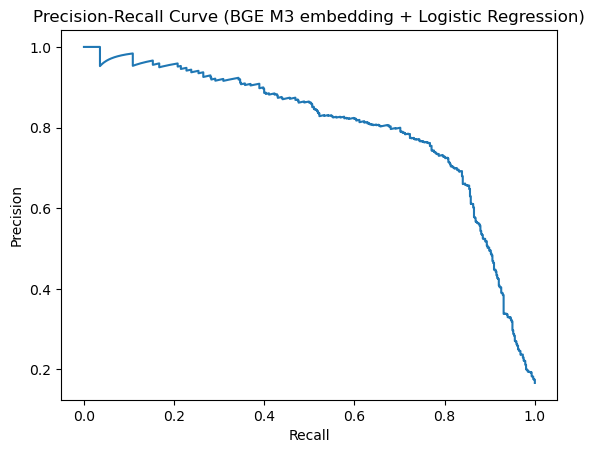

In [11]:
lr = LogisticRegression(max_iter=300,class_weight='balanced',n_jobs=-1)
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["safe", "risk"]))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve (BGE M3 embedding + Logistic Regression)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

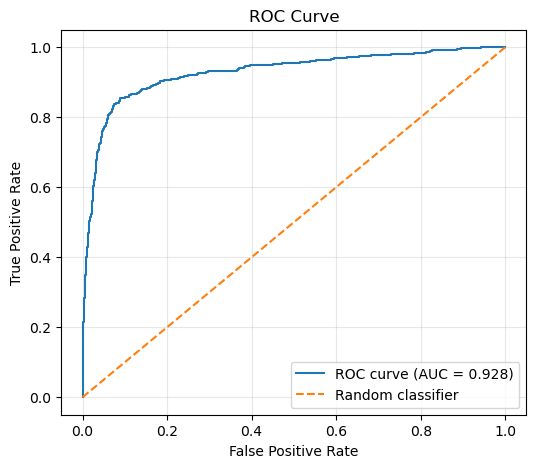

In [12]:
y_true = y_test
y_prob = lr.predict_proba(X_test)[:,1]  

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--', label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [14]:
pos = (y_train ==1).sum()
neg = (y_train == 0).sum()
scale_pos_neg = neg/pos


xgb = XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",    
    device="cuda",   
    eval_metric='auc',
    random_state=42
)


param_distributions = {
    "n_estimators":[200,400,600],
    "max_depth": [ 4,6,8],
    "learning_rate":[0.05,0.1],
    "subsample":[0.8,1],
    "colsample_bytree":[0.8,1]
}


cv = StratifiedKFold(n_splits=3,shuffle=True,random_state=42)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=15,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    refit=True
)


search.fit(X_train,y_train)

print("Best Params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)


best_model = search.best_estimator_
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
print("Validation ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

y_pred = (y_pred_proba > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/home1/salkar/.conda/envs/tan_env/lib/python3.10/site-packages/xgboost/core.py:774: UserWarning: [18:54:03] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home1/salkar/.conda/envs/tan_env/lib/python3.10/site-packages/xgboost/core.py:774: UserWarning: [18:54:04] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in th

Best Params: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1}
Best CV ROC-AUC: 0.9584377468248361
Validation ROC-AUC: 0.9602029293095524
              precision    recall  f1-score   support

           0     0.9541    0.9744    0.9642      2817
           1     0.8569    0.7655    0.8086       563

    accuracy                         0.9396      3380
   macro avg     0.9055    0.8700    0.8864      3380
weighted avg     0.9379    0.9396    0.9383      3380



/home1/salkar/.conda/envs/tan_env/lib/python3.10/site-packages/xgboost/core.py:774: UserWarning: [18:56:18] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


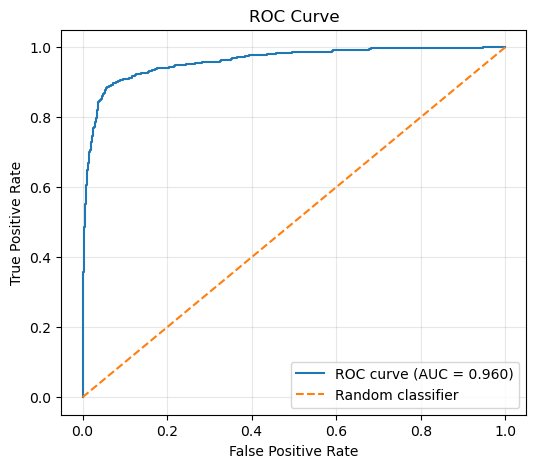

[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=600, subsample=0.8; total time=   5.9s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=6, n_estimators=400, subsample=0.8; total time=   5.5s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=6, n_estimators=400, subsample=0.8; total time=   6.2s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=4, n_estimators=200, subsample=0.8; total time=   2.7s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=4, n_estimators=200, subsample=0.8; total time=   2.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8; total time=   2.7s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, n_estimators=600, subsample=0.8; total time=   7.8s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, n_estimators=600, subsample=0.8; total time=   8.5s
[CV] END colsample_bytree=1, learning_rate=0.05, max_depth=8, n_estimators=400, su

In [15]:
y_prob = best_model.predict_proba(X_test)[:,1]  
y_prob_train = best_model.predict_proba(X_train)[:,1]  
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--', label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()